# Plant Disease Classification with a Convolutional Neural Network

**Week 4 project.** This notebook builds an image classifier for the PlantVillage dataset. It loads images from class-named folders, checks class balance and image quality, creates stratified train/validation/test sets, trains a CNN, evaluates the held-out test set, inspects errors, and saves a model for later inference.

> **Scope note:** The assignment problem statement mentions wheat, while PlantVillage contains 14 crop types and 38 crop/disease classes, not a wheat-only dataset. This notebook therefore predicts among PlantVillage classes. A wheat-specific classifier needs a labeled wheat-leaf dataset and a fresh training run. PlantVillage images are controlled leaf images, so strong test performance does not guarantee field performance.


## 1. Setup and imports

The model uses PyTorch and a small CNN trained from scratch. Images are resized to 128×128 RGB pixels and normalized to [0,1]. If a CUDA GPU is available, training uses it; otherwise CPU training is supported but may take considerably longer.


In [3]:
# If needed, install in your environment before running the notebook:
# %pip install torch torchvision scikit-learn matplotlib seaborn pillow

from pathlib import Path
import random, os, copy, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_recall_fscore_support,
                             ConfusionMatrixDisplay)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__, '| device:', DEVICE)
ImageFile.LOAD_TRUNCATED_IMAGES = False


PyTorch: 2.14.0 | device: cpu


## 2. Dataset location and class labels

Download PlantVillage from [Kaggle](https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset) and extract it. Point `DATA_DIR` at the directory whose immediate subfolders are class names. Some Kaggle archives add a wrapper directory such as `PlantVillage` or `color`; set the path to the directory containing the class folders.

Example layout:

```text
plant_disease_classification/
├── Plant_Disease_CNN.ipynb
└── data/PlantVillage/                 # DATA_DIR
    ├── Apple___Apple_scab/
    │   ├── image_001.jpg
    │   └── ...
    ├── Apple___healthy/
    └── ...
```

Do not point to the outer archive directory if it contains only a single wrapper folder. The code will stop with a clear message if it cannot find class folders.


In [4]:
DATA_DIR = Path("data/raw/color")
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Dataset folder not found: {DATA_DIR.resolve()}. Download and extract PlantVillage, then set DATA_DIR.")
class_dirs = sorted(p for p in DATA_DIR.iterdir() if p.is_dir())
if len(class_dirs) < 2:
    raise ValueError(f'Expected class subfolders inside {DATA_DIR}; found {len(class_dirs)}.')
class_names = [p.name for p in class_dirs]
class_to_idx = {name:i for i,name in enumerate(class_names)}
records = [(str(path), class_to_idx[d.name]) for d in class_dirs
           for path in d.rglob('*') if path.is_file() and path.suffix.lower() in IMAGE_EXTS]
if not records:
    raise ValueError('No supported images found (.jpg, .jpeg, .png, .bmp).')
files = np.array([r[0] for r in records]); labels = np.array([r[1] for r in records])
counts = pd.Series(labels).value_counts().reindex(range(len(class_names)), fill_value=0)
class_summary = pd.DataFrame({'class':class_names, 'images':counts.values})
print(f'{len(files):,} images | {len(class_names)} classes')
class_summary.sort_values('images').head(10)

54,305 images | 38 classes


,class,images
22,Potato___healthy,152
2,Apple___Cedar_apple_rust,275
17,Peach___healthy,360
23,Raspberry___healthy,371
36,Tomato___Tomato_mosaic_virus,373
14,Grape___healthy,423
27,Strawberry___healthy,456
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,513
1,Apple___Black_rot,621
0,Apple___Apple_scab,630


## 3. Data quality checks and exploratory analysis

Folder names act as labels. We check class counts and open a random sample to confirm files are readable and labels align with the folder structure. Corrupt images are excluded after a validation pass. We keep the original class labels and do not impute image pixels; damaged files cannot provide meaningful visual evidence, so we skip them and report the count.


<Figure size 1200x836 with 0 Axes>

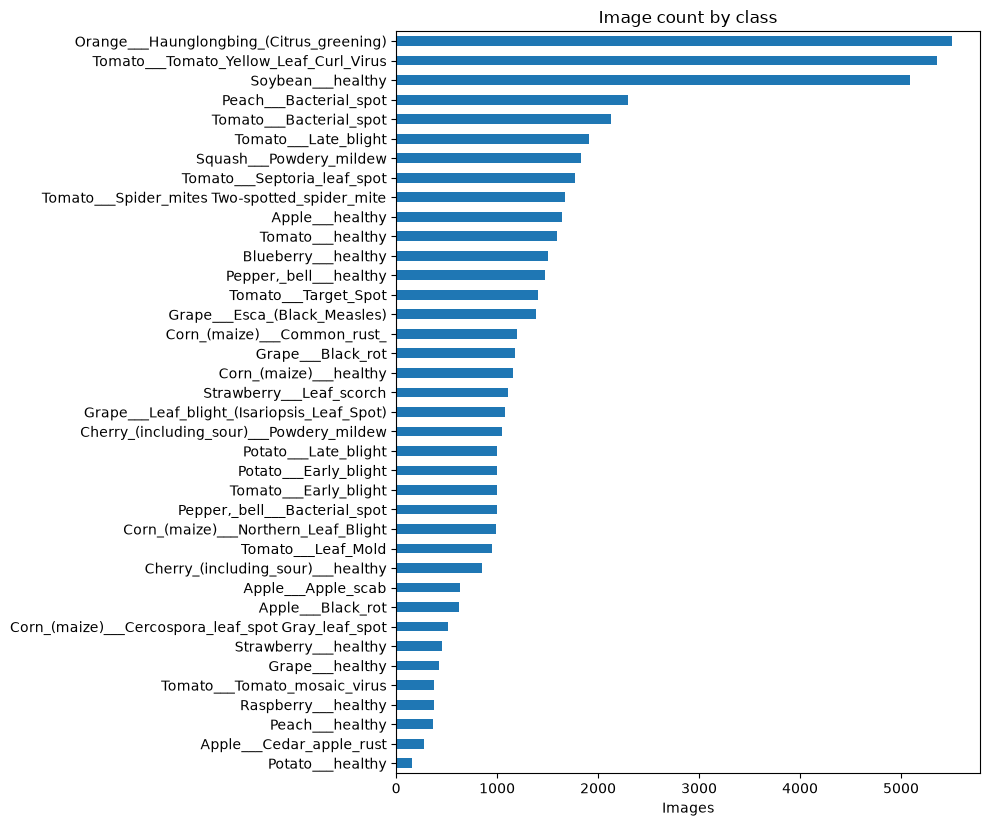

In [5]:
plt.figure(figsize=(12, max(6, len(class_names)*0.22)))
class_summary.sort_values('images').plot.barh(x='class', y='images', legend=False, figsize=(10,max(6,len(class_names)*.22)))
plt.title('Image count by class'); plt.xlabel('Images'); plt.ylabel(''); plt.tight_layout(); plt.show()

In [6]:
# Verify image readability and expected RGB conversion. This pass can take a few minutes.
valid = []
bad_files = []
for path, label in zip(files, labels):
    try:
        with Image.open(path) as im:
            im.verify()
        valid.append((path, int(label)))
    except Exception:
        bad_files.append(path)
files = np.array([r[0] for r in valid]); labels = np.array([r[1] for r in valid])
print('Readable images:', len(files), '| skipped corrupt/unreadable:', len(bad_files))

Readable images: 54305 | skipped corrupt/unreadable: 0


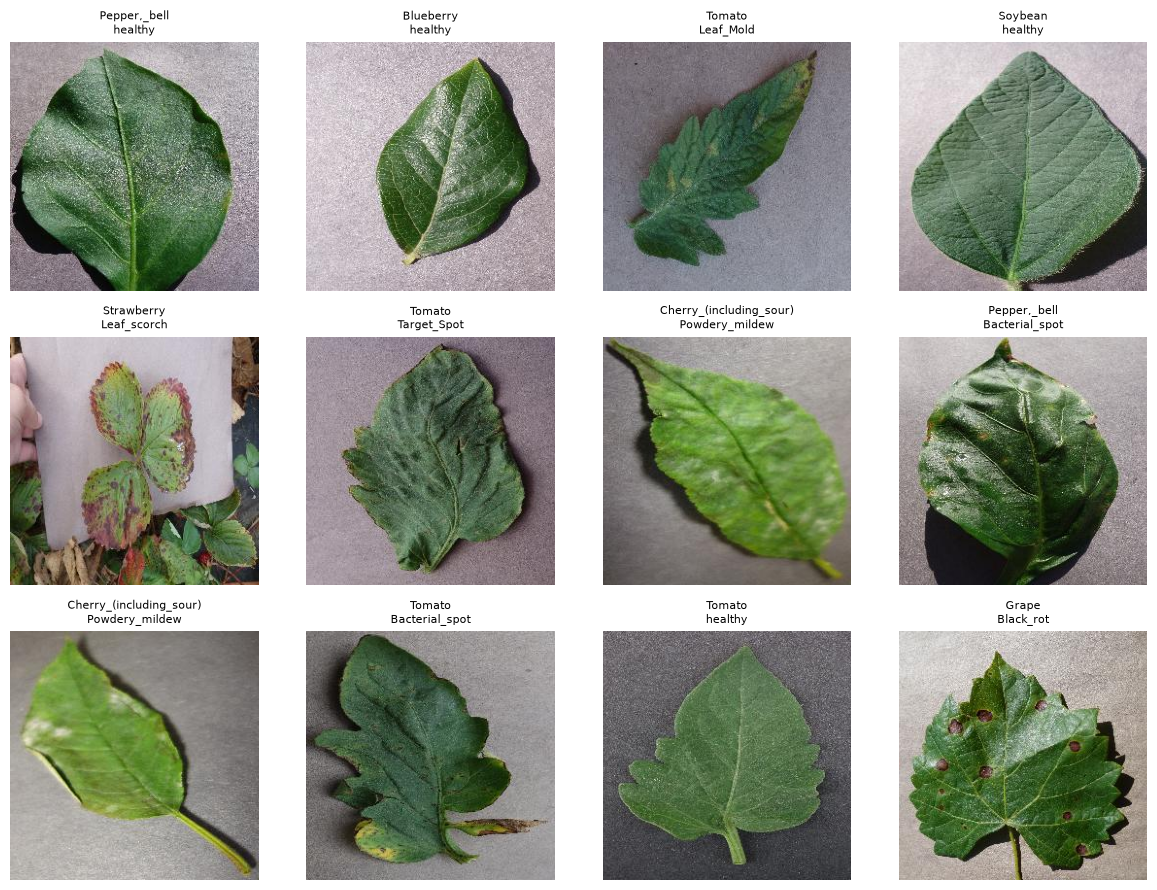

In [7]:
rng = np.random.default_rng(SEED)
chosen = rng.choice(len(files), size=min(12,len(files)), replace=False)
fig, axes = plt.subplots(3,4,figsize=(12,9))
for ax, idx in zip(axes.flat, chosen):
    with Image.open(files[idx]) as im: ax.imshow(im.convert('RGB'))
    ax.set_title(class_names[labels[idx]].replace('___','\n'), fontsize=8); ax.axis('off')
plt.tight_layout()


The image samples and counts are quality checks, not evidence that field conditions are represented. PlantVillage photos typically show isolated leaves against relatively clean backgrounds, unlike phone images taken outdoors with varied lighting, backgrounds, and overlapping leaves.

## 4. Stratified train / validation / test split

We split file paths and labels into 70% training, 15% validation, and 15% test, stratifying each split so every class is represented proportionally. The test set is held out until final evaluation. Validation performance selects the best epoch and supports early stopping. Augmentation is applied only to training images to reduce overfitting; validation/test receive deterministic resizing and normalization.


In [8]:
train_files, temp_files, train_y, temp_y = train_test_split(
    files, labels, test_size=0.30, random_state=SEED, stratify=labels)
val_files, test_files, val_y, test_y = train_test_split(
    temp_files, temp_y, test_size=0.50, random_state=SEED, stratify=temp_y)
print(f'Train: {len(train_files):,} ({len(train_files)/len(files):.1%})')
print(f'Validation: {len(val_files):,} ({len(val_files)/len(files):.1%})')
print(f'Test: {len(test_files):,} ({len(test_files)/len(files):.1%})')


Train: 38,013 (70.0%)
Validation: 8,146 (15.0%)
Test: 8,146 (15.0%)


## 5. Preprocessing, augmentation, and class weights

The training transform uses small rotations, horizontal flips, and mild brightness/contrast changes. These are reasonable variations for leaf photographs, but rotations/flips do not represent every real-world change. We avoid aggressive color transformations because color can carry disease information. Class weights make mistakes on less common classes contribute more to the training loss. Validation and test data are never augmented.


In [9]:
IMAGE_SIZE = 128
BATCH_SIZE = 64 if DEVICE.type == 'cuda' else 32
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.12, contrast=0.12),
    transforms.ToTensor(),
])
eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])
class LeafDataset(Dataset):
    def __init__(self, paths, targets, transform):
        self.paths, self.targets, self.transform = list(paths), list(targets), transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        with Image.open(self.paths[idx]) as im:
            image = im.convert('RGB')
        return self.transform(image), int(self.targets[idx])

train_ds = LeafDataset(train_files, train_y, train_transform)
val_ds = LeafDataset(val_files, val_y, eval_transform)
test_ds = LeafDataset(test_files, test_y, eval_transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=(DEVICE.type=='cuda'))
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(DEVICE.type=='cuda'))
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(DEVICE.type=='cuda'))
class_counts = np.bincount(train_y, minlength=len(class_names))
class_weights = len(train_y) / (len(class_names) * np.maximum(class_counts,1))
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
print('Class weight range:', float(class_weights.min()), 'to', float(class_weights.max()))


Class weight range: 0.2594921290874481 to 9.437190055847168


## 6. CNN architecture

A CNN applies learned filters across image regions. Convolution and pooling blocks learn increasingly complex visual patterns; global average pooling reduces parameters; dropout regularizes the classifier; the final linear layer returns one score (logit) for each class. Cross-entropy loss compares these logits with the correct class.


In [10]:
class PlantCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128,192,3,padding=1), nn.BatchNorm2d(192), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1,1)),
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.35), nn.Linear(192,n_classes))
    def forward(self,x): return self.classifier(self.features(x))

model = PlantCNN(len(class_names)).to(DEVICE)
print(model)
print('Trainable parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))


PlantCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine

## 7. Training methodology

Training uses Adam with learning rate 0.001, weighted cross-entropy, and validation-loss early stopping (patience 3). We save the weights with the lowest validation loss and restore them after training. The maximum epoch count is 15; early stopping may finish sooner. Record actual epochs and scores from your run rather than reporting expected results.


In [14]:
from tqdm.auto import tqdm

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

MAX_EPOCHS = 15
EARLY_STOP_PATIENCE = 3
LR_PATIENCE = 2
LR_FACTOR = 0.5
MIN_LR = 1e-5

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=LR_FACTOR,
    patience=LR_PATIENCE,
    min_lr=MIN_LR
)

def run_epoch(loader, training=False, epoch=1, phase="Train"):
    model.train(training)
    total_loss, correct, total = 0.0, 0, 0

    progress = tqdm(
        loader,
        desc=f"Epoch {epoch}/{MAX_EPOCHS} [{phase}]",
        leave=False
    )

    for xb, yb in progress:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            logits = model(xb)
            loss = criterion(logits, yb)

            if training:
                loss.backward()
                optimizer.step()

        batch_size = len(yb)
        total_loss += loss.item() * batch_size
        correct += (logits.argmax(1) == yb).sum().item()
        total += batch_size

        progress.set_postfix(
            loss=f"{total_loss / total:.4f}",
            accuracy=f"{correct / total:.4f}"
        )

    return total_loss / total, correct / total


history = []
best_val_loss = float("inf")
best_state = None
stale = 0

for epoch in range(1, MAX_EPOCHS + 1):
    start = time.time()

    train_loss, train_acc = run_epoch(
        train_loader, training=True, epoch=epoch, phase="Train"
    )
    val_loss, val_acc = run_epoch(
        val_loader, training=False, epoch=epoch, phase="Validation"
    )

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_accuracy": train_acc,
        "val_accuracy": val_acc,
        "learning_rate": current_lr
    })

    print(
        f"Epoch {epoch}/{MAX_EPOCHS} - "
        f"{time.time() - start:.1f}s - "
        f"accuracy: {train_acc:.4f} - loss: {train_loss:.4f} - "
        f"val_accuracy: {val_acc:.4f} - val_loss: {val_loss:.4f} - "
        f"learning_rate: {current_lr:.4g}",
        flush=True
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        stale = 0
    else:
        stale += 1
        if stale >= EARLY_STOP_PATIENCE:
            print("Early stopping: validation loss did not improve.", flush=True)
            break

if best_state is not None:
    model.load_state_dict(best_state)

history_df = pd.DataFrame(history)


Epoch 1/15 [Train]:   0%|          | 0/1188 [00:00<?, ?it/s]

Epoch 1/15 [Validation]:   0%|          | 0/255 [00:00<?, ?it/s]

Epoch 1/15 - 451.8s - accuracy: 0.7359 - loss: 0.8809 - val_accuracy: 0.6919 - val_loss: 1.0467 - learning_rate: 0.001


Epoch 2/15 [Train]:   0%|          | 0/1188 [00:00<?, ?it/s]

Epoch 2/15 [Validation]:   0%|          | 0/255 [00:00<?, ?it/s]

...

Epoch 8/15 [Validation]:   0%|          | 0/255 [00:00<?, ?it/s]

Epoch 8/15 - 432.1s - accuracy: 0.9190 - loss: 0.2413 - val_accuracy: 0.9401 - val_loss: 0.1866 - learning_rate: 0.001


Epoch 9/15 [Train]:   0%|          | 0/1188 [00:00<?, ?it/s]

Epoch 9/15 [Validation]:   0%|          | 0/255 [00:00<?, ?it/s]

Epoch 9/15 - 515.6s - accuracy: 0.9264 - loss: 0.2247 - val_accuracy: 0.9484 - val_loss: 0.1787 - learning_rate: 0.0005
Early stopping: validation loss did not improve.


## 8. Evaluation: metrics and learning curves

We report accuracy, macro precision/recall/F1, and weighted F1. Macro metrics give each class equal weight, making them useful when class sizes differ; weighted metrics reflect the class frequencies. The final metrics are calculated once on the untouched test split using the best validation checkpoint.


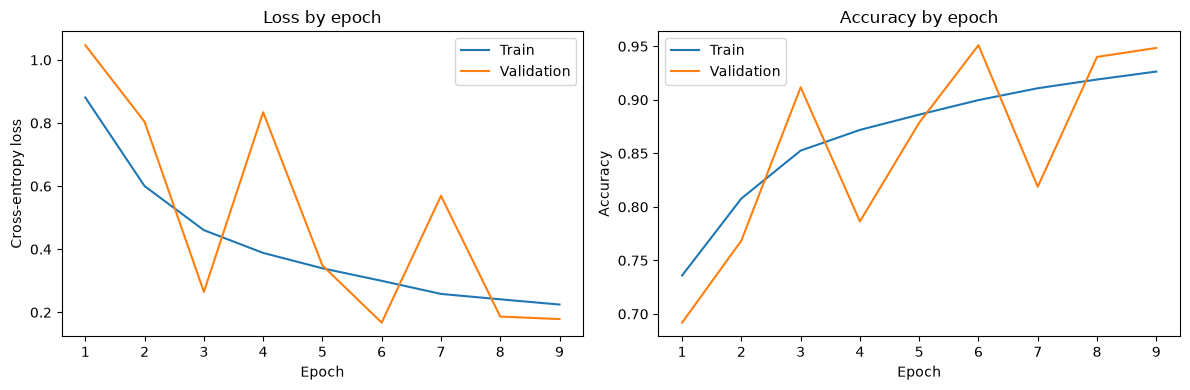

In [15]:
fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].plot(history_df.epoch,history_df.train_loss,label='Train'); axes[0].plot(history_df.epoch,history_df.val_loss,label='Validation')
axes[0].set(title='Loss by epoch',xlabel='Epoch',ylabel='Cross-entropy loss'); axes[0].legend()
axes[1].plot(history_df.epoch,history_df.train_accuracy,label='Train'); axes[1].plot(history_df.epoch,history_df.val_accuracy,label='Validation')
axes[1].set(title='Accuracy by epoch',xlabel='Epoch',ylabel='Accuracy'); axes[1].legend()
plt.tight_layout()

In [16]:
model.eval(); y_true=[]; y_pred=[]; y_prob=[]
with torch.no_grad():
    for xb,yb in test_loader:
        logits=model(xb.to(DEVICE)); probs=torch.softmax(logits,dim=1).cpu().numpy()
        y_prob.extend(probs); y_pred.extend(probs.argmax(axis=1)); y_true.extend(yb.numpy())
y_true=np.array(y_true); y_pred=np.array(y_pred); y_prob=np.array(y_prob)
print('Test accuracy:', f'{accuracy_score(y_true,y_pred):.4f}')
print(classification_report(y_true,y_pred,target_names=class_names,zero_division=0,digits=3))

Test accuracy: 0.9503
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab      0.987     0.830     0.902        94
                                 Apple___Black_rot      0.967     0.946     0.957        93
                          Apple___Cedar_apple_rust      1.000     0.902     0.949        41
                                   Apple___healthy      0.907     0.955     0.931       246
                               Blueberry___healthy      0.961     0.978     0.969       226
          Cherry_(including_sour)___Powdery_mildew      1.000     0.956     0.977       158
                 Cherry_(including_sour)___healthy      0.947     0.984     0.966       128
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      0.763     0.961     0.851        77
                       Corn_(maize)___Common_rust_      0.994     0.994     0.994       179
               Corn_(maize)___Northern_Leaf_Blight      0

ROC-AUC can be reported as a macro one-vs-rest score for a multiclass task, but it requires probabilities and can be expensive to compute for all classes. The per-class precision/recall/F1 report and confusion matrix are the primary class-level diagnostics here.

## 9. Error analysis

A confusion matrix shows which classes the model mixes up. We also inspect misclassified images with true labels, predicted labels, and confidence. Visually similar diseases can be difficult even when the model is trained correctly; incorrect folder labels, background shortcuts, and out-of-distribution field photos are other possibilities. Misclassified examples are not proof of the cause, so use them to guide targeted data checks.


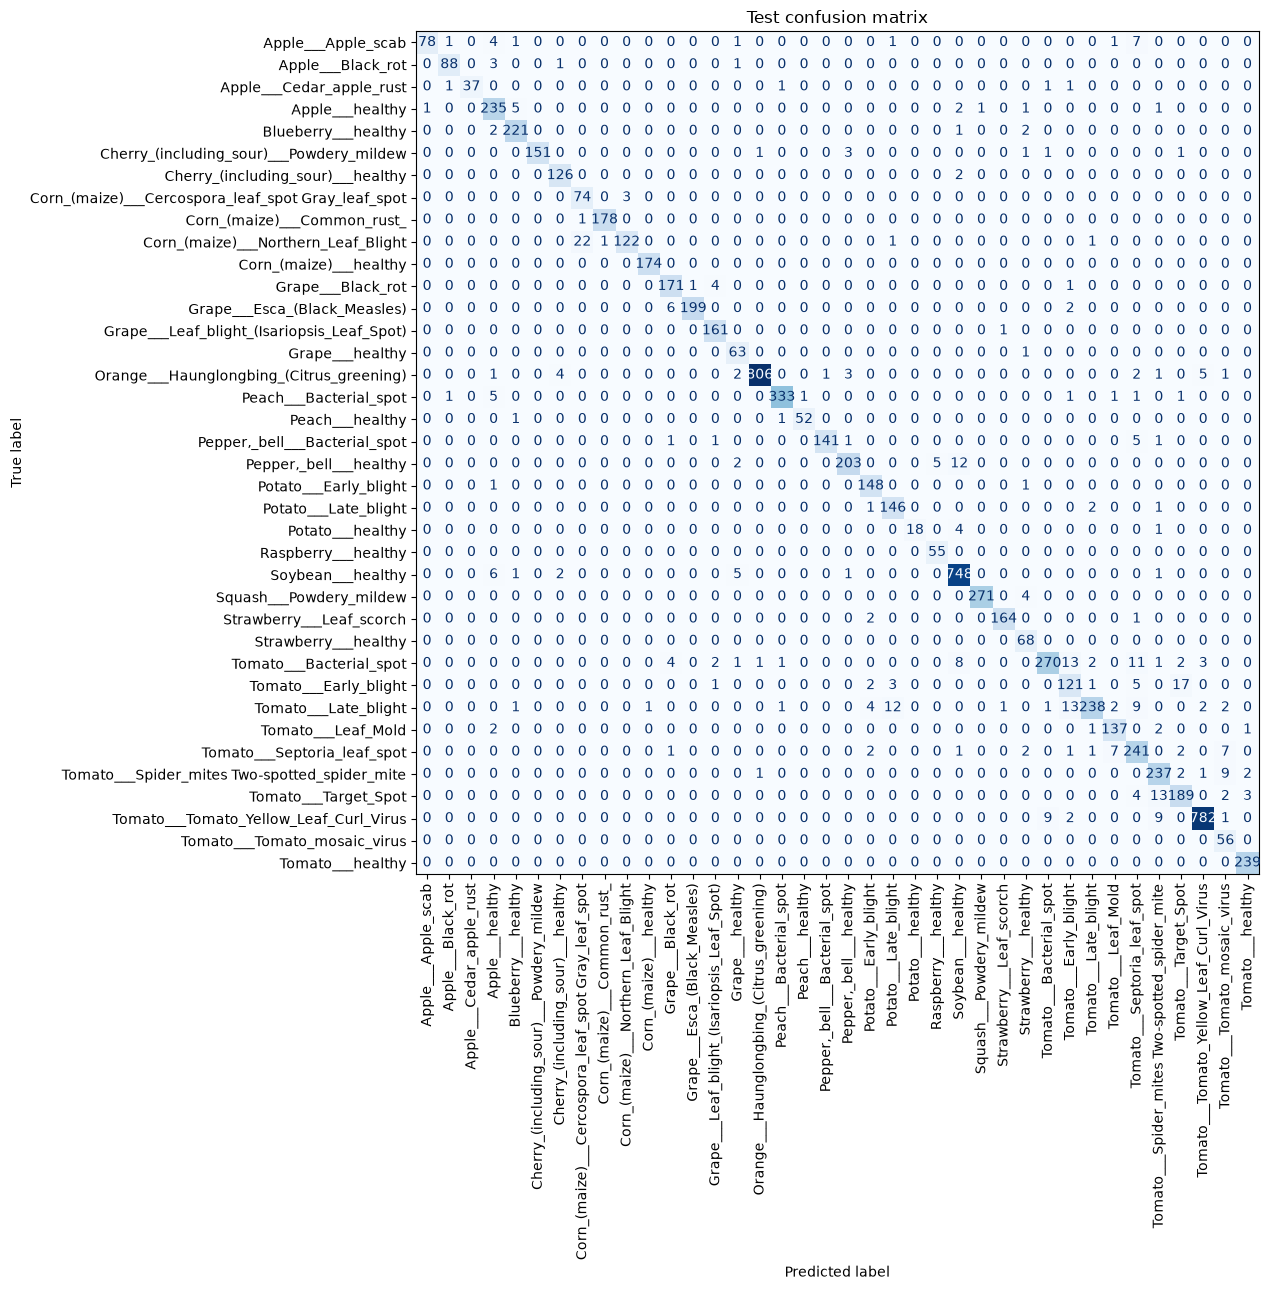

In [17]:
cm=confusion_matrix(y_true,y_pred,labels=np.arange(len(class_names)))
fig,ax=plt.subplots(figsize=(15,13))
disp=ConfusionMatrixDisplay(cm,display_labels=class_names)
disp.plot(ax=ax,xticks_rotation=90,cmap='Blues',colorbar=False,values_format='d')
plt.title('Test confusion matrix'); plt.tight_layout()

Misclassified test images: 405 of 8146


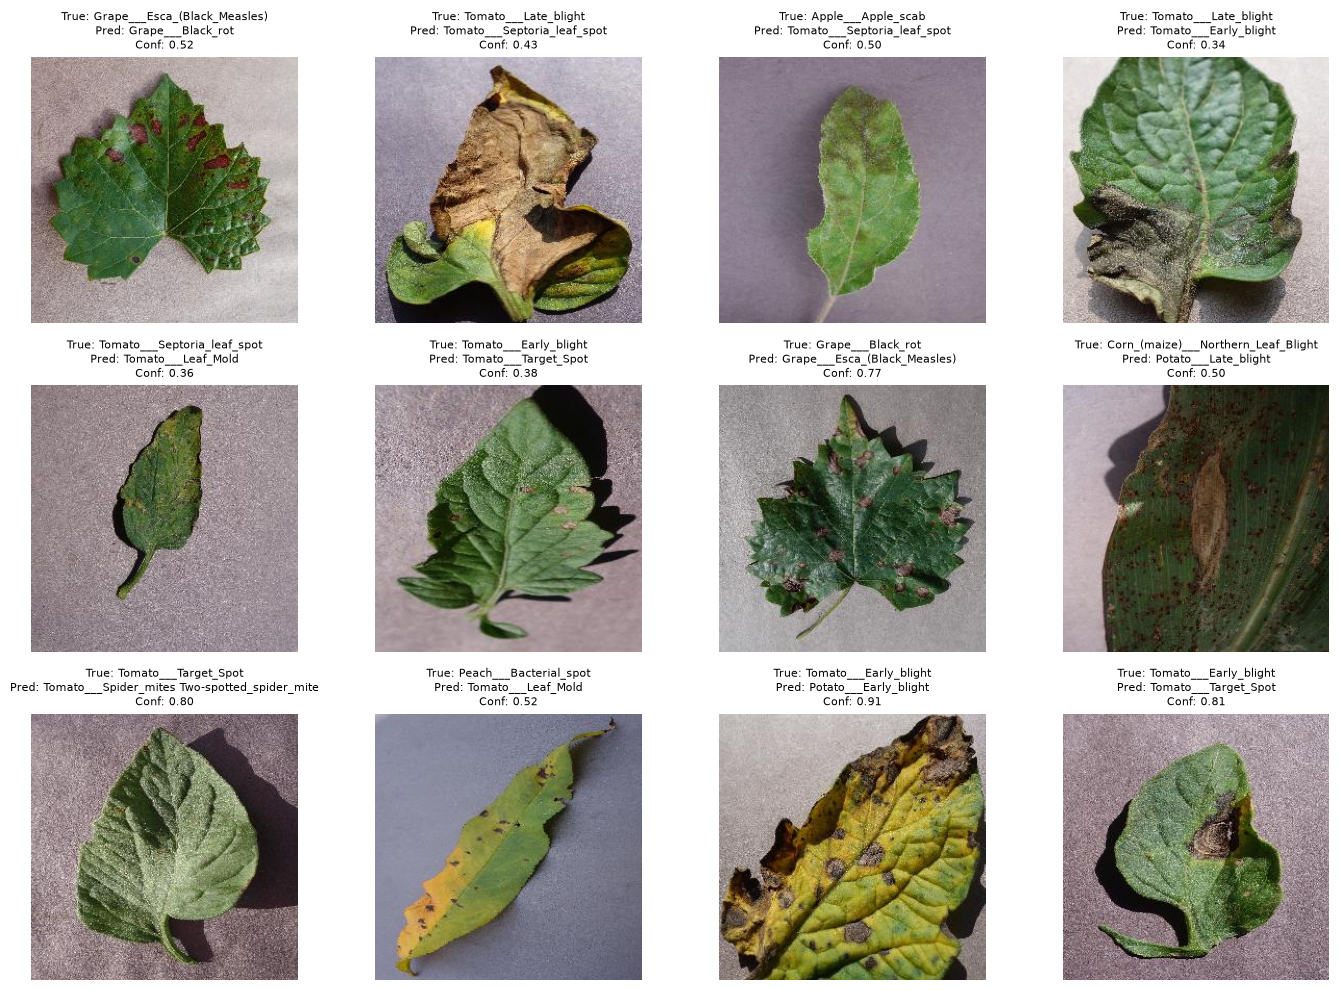

In [18]:
mis_idx=np.flatnonzero(y_true!=y_pred)
print('Misclassified test images:',len(mis_idx),'of',len(y_true))
if len(mis_idx):
    show=np.random.default_rng(SEED).choice(mis_idx,size=min(12,len(mis_idx)),replace=False)
    fig,axes=plt.subplots(3,4,figsize=(14,10))
    for ax,i in zip(axes.flat,show):
        with Image.open(test_files[i]) as im: ax.imshow(im.convert('RGB'))
        ax.set_title(f'True: {class_names[y_true[i]]}\nPred: {class_names[y_pred[i]]}\nConf: {y_prob[i].max():.2f}',fontsize=8)
        ax.axis('off')
    for ax in axes.flat[len(show):]: ax.axis('off')
    plt.tight_layout()
else:
    print('No errors to display on this test split.')


### Error reduction options

Use the error patterns to decide what to try next: collect more examples for weak classes, check mislabeled or low-quality files, add field images with varied backgrounds, and compare a transfer-learning model such as MobileNetV3. Test one change at a time and keep the same held-out test set untouched until the final comparison. If repeated experimentation uses test results to choose changes, create a new final test set.

## 10. Sample-image prediction

The helper below loads a single image, applies the same deterministic preprocessing used at evaluation, and returns the top predictions. Change `SAMPLE_IMAGE` to a local image path. The predicted class is a model output, not a definitive diagnosis; field decisions should be confirmed by an agricultural specialist.


In [2]:
def predict_image(image_path, top_k=3):
    image_path=Path(image_path)
    with Image.open(image_path) as im: image=eval_transform(im.convert('RGB')).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad(): probs=torch.softmax(model(image),dim=1)[0].cpu().numpy()
    top=np.argsort(probs)[::-1][:top_k]
    return pd.DataFrame({'class':[class_names[i] for i in top],'probability':[float(probs[i]) for i in top]})

SAMPLE_IMAGE = 'data/raw/color/Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot/0a01cc10-3892-4311-9c48-0ac6ab3c7c43___RS_GLSp 9352.JPG'


## 11. Conclusion

This project demonstrates a CNN pipeline for classifying PlantVillage leaf images, with stratified data splits, train-only augmentation, class-weighted loss, validation-based early stopping, and held-out test analysis. Report the actual values printed during your run and discuss the weakest classes shown by the classification report and confusion matrix.

The dataset supports a 38-class PlantVillage crop/disease task, not a wheat-only task. It also contains curated leaf images, so field generalization remains unverified. A wheat-focused extension should use a wheat-specific dataset with images from varied field settings, then repeat the same train/validation/test discipline.

**Source:** Hughes, D. P. and Salathé, M. (2015), *An open access repository of images on plant health to enable the development of mobile disease diagnostics*, arXiv:1511.08060; PlantVillage dataset distributed via [Kaggle](https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset). The assignment brief provides the project scope. Add any course-required disclosure of assistance or external code before submission.
